<a href="https://colab.research.google.com/github/e-a-mansson/AG2418-Final-Project/blob/main/AG2418_Project_V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mono-Forward: A Backpropagation Free Learning Algorithm**
## **Classification in Geospatial Data**
Final project for AG2418 - Geospatial Artificial
Intelligence (GeoAI)

KTH Royal Institute of Technology

Stockholm, Sweden, 2026

Author: *Erik Månsson*

**References:**
  * J. Gong, B. Li, and W. Abdulla, “Mono-Forward: Backpropagation-Free Algorithm for Efficient Neural Network Training Harnessing Local Errors,” Jan. 2025, doi: 10.48550/arxiv.2501.09238.
  * P. Spyra and W. Dzwinel, “Energy-Efficient Deep Learning Without Backpropagation: A Rigorous Evaluation of Forward-Only Algorithms,” Nov. 2025, doi: 10.48550/arxiv.2511.01061.
  * ResNet18: https://medium.com/biased-algorithms/building-resnet18-from-scratch-using-pytorch-64c6619432f2
  * MF Python implementation: https://github.com/surfingtheuniverse/Colab-Mono-Forward/blob/main/Copy_of_Beyond_Backprop_FF_CaFo_MF_Colab_Testbed.ipynb

**AI Statement:** Generative AI has been used for this project. Usage includes help with conversion of MF-algorithm from MLP to CNN, implementation of K-Fold Cross Validation, gradient flow checks and other tests. Care was taken when prompting to ensure questions were neutral. Multiple follow up prompts were also given to try to ensure accurate answers, in addition to double checking by the author and by other AI models.

Models used:
  * Gemini 2.5 Flash
  * Gemini 3 Pro
  * Copilot

In [27]:
#@title Configs
batch_size = 256
percent_split = 0.1
max_epochs = 50
lr_bp = 0.001
lr_mf = 0.001
patience = 2
use_energy_tracking = True
use_early_stopping = False
print_every_epochs = 10
k_folds = 5

# Available Datasets: ['MNIST', 'FashionMNIST', 'CIFAR10', 'UCMerced']
dataset_names = ['UCMerced']

# Models: ['MLP', 'CNN_BP', 'MFNet', 'CNN_MF', 'ResNet18', 'ResNet_MF', 'Plain18_MFNet', 'Plain18_BP']
model_names = ['Plain18_MFNet', 'Plain18_BP', 'ResNet18', 'ResNet_MF']

In [2]:
#@title Imports
import os, math, random, time
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple
import matplotlib.pyplot as plt
import gc

!pip install torchgeo
import torchgeo
import torchgeo.datasets
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.datasets
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler


try:
    import pynvml
    _HAS_NVML = True
except Exception:
    _HAS_NVML = False


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__, 'CUDA:', torch.cuda.is_available(), 'Device:', DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
#@title Defining datasets and *get_data* function

class ImageTransform(torch.nn.Module):
    def __init__(self, transform):
        super().__init__()
        self.transform = transform

    def forward(self, sample):
        sample['image'] = self.transform(sample['image'])
        return sample


dataset_info = {
    'MNIST': {
        'class': torchvision.datasets.MNIST,
        'in_channels': 1,
        'n_classes': 10,
        'img_size': 28,
        'mean_std': ((0.1307,), (0.3081,)),
        'is_rgb': False
    },
    'FashionMNIST': {
        'class': torchvision.datasets.FashionMNIST,
        'in_channels': 1,
        'n_classes': 10,
        'img_size': 28,
        'mean_std': ((0.2860,), (0.3530,)),
        'is_rgb': False
    },
    'CIFAR10': {
        'class': torchvision.datasets.CIFAR10,
        'in_channels': 3,
        'n_classes': 10,
        'img_size': 32,
        'mean_std': ((0.4914, 0.4822, 0.4465),(0.2023, 0.1994, 0.2010)),
        'is_rgb': True
    },
    'UCMerced': {
        'class': torchgeo.datasets.UCMerced,
        'in_channels': 3,
        'n_classes': 21,
        'img_size': 256,
        'mean_std': ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        'is_rgb': True
    }
}

def get_data(batch_size: int, percent_split: float, dataset_name: str):
    info = dataset_info.get(dataset_name)
    if info is None:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    IN_CH = info['in_channels']
    NCLS = info['n_classes']
    IMG = info['img_size']
    DatasetClass = info['class']
    mean, std = info['mean_std']
    is_rgb = info['is_rgb']

    # --- Define Transforms ---

    # Base steps (To Tensor + Normalize)
    base_steps = [T.ToTensor()]
    if not is_rgb and IN_CH == 3:
        base_steps.append(T.Grayscale(num_output_channels=3))
    base_steps.append(T.Normalize(mean, std))

    # Eval Transform (Clean)
    tv_eval_transform = T.Compose(base_steps)

    # Train Transform (Augmentation + Base)
    train_aug = []
    if is_rgb:
        # CIFAR10 / UCMerced Logic
        if IMG <= 64: # Small images (CIFAR)
            train_aug.append(T.RandomCrop(IMG, padding=4))
        else: # Large images (UCMerced)
            train_aug.append(T.RandomResizedCrop(IMG, scale=(0.8, 1.0), antialias=True))

        train_aug.append(T.RandomHorizontalFlip())
        if dataset_name == 'UCMerced':
             train_aug.append(T.RandomVerticalFlip())
    else:
        # MNIST / FashionMNIST Logic (Simple crop, usually no flip)
        train_aug.append(T.RandomCrop(IMG, padding=4))

    train_aug.extend(base_steps)
    tv_train_transform = T.Compose(train_aug)

    # TorchGeo specific transforms (UCMerced)
    if dataset_name == 'UCMerced':
        # Eval
        tg_eval_transform = ImageTransform(T.Compose([
            lambda x: x.float() / 255.0,
            T.Normalize(mean, std)
        ]))

        # Train
        tg_aug_list = []
        if IMG > 64:
             tg_aug_list.append(T.RandomResizedCrop(IMG, scale=(0.8, 1.0), antialias=True))
        tg_aug_list.append(T.RandomHorizontalFlip())
        tg_aug_list.append(T.RandomVerticalFlip())
        tg_aug_list.append(lambda x: x.float() / 255.0)
        tg_aug_list.append(T.Normalize(mean, std))
        tg_train_transform = ImageTransform(T.Compose(tg_aug_list))

    # --- Load Datasets ---
    if dataset_name == 'UCMerced':
        # Load disjointly to assign different transforms
        ds_train_aug = DatasetClass(root='./data', split='train', download=True, checksum=True, transforms=tg_train_transform)
        ds_train_clean = DatasetClass(root='./data', split='train', download=True, checksum=True, transforms=tg_eval_transform)
        test_dataset = DatasetClass(root='./data', split='val', download=True, transforms=tg_eval_transform)
    else:
        ds_train_aug = DatasetClass(root='./data', train=True, download=True, transform=tv_train_transform)
        ds_train_clean = DatasetClass(root='./data', train=True, download=True, transform=tv_eval_transform)
        test_dataset = DatasetClass(root='./data', train=False, download=True, transform=tv_eval_transform)

    # --- Split Train/Val ---
    total_len = len(ds_train_aug)
    n_val = int(percent_split * total_len)
    n_tr = total_len - n_val

    # Generate fixed random indices for splitting
    indices = torch.randperm(total_len).tolist()
    train_indices = indices[:n_tr]
    val_indices = indices[n_tr:]

    # Create Subsets: Train gets Aug, Val gets Clean
    train_split = Subset(ds_train_aug, train_indices)
    val_split = Subset(ds_train_clean, val_indices)

    print(f"Number of training samples: {len(train_split)}")
    print(f"Number of validation samples: {len(val_split)}")

    dl_train = DataLoader(train_split, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    dl_val   = DataLoader(val_split, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_test  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return dl_train, dl_val, dl_test, IN_CH, NCLS, IMG

# Models and auxiliary functions

In [9]:
#@title Initialise weights

def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

In [4]:
#@title MLP

class MLP(nn.Module):
    def __init__(self, in_dim, ncls, hidden: List[int]):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden:
            layers += [nn.Linear(last, h), nn.ReLU(inplace=True)]
            last = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(last, ncls)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.backbone(x)
        return self.head(z)

In [7]:
#@title MFNet

class MFBlock(nn.Module):
    def __init__(self, in_dim, out_dim, ncls):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(inplace=True)
        )
        self.classifier = nn.Linear(out_dim, ncls, bias=False)

    def forward(self, x):
        out = self.layer(x)
        return out, self.classifier(out)


class MFNet(nn.Module):
    def __init__(self, in_dim, ncls, layers: List[int]):
        super().__init__()
        dims = [in_dim] + layers
        self.blocks = nn.ModuleList([MFBlock(dims[i], dims[i+1], ncls) for i in range(len(layers))])
        self.ncls = ncls

    def forward_all(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        acts, scores = [], []
        for b in self.blocks:
            x, g = b(x)
            acts.append(x); scores.append(g)
            x = x.detach()
        return acts, scores

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        _, scores = self.forward_all(x)
        return scores[-1]

    def train_step(self, x, y, optimizer):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        # Sequential training loop
        for b in self.blocks:
            x, g = b(x)
            loss = F.cross_entropy(g, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            x = x.detach() # Detach for next block input to save memory/graph

        return g # Return final score

In [5]:
#@title CNN (BP)

class CNN_BP(nn.Module):
    def __init__(self, in_channels, img_size, ncls, conv_filters: List[int], mlp_hidden_dims: List[int]):
        super().__init__()
        self.ncls = ncls
        current_channels = in_channels
        current_img_size = img_size

        conv_layers = []
        for out_channels in conv_filters:
            conv_layers += [
                nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.AvgPool2d(kernel_size=2, stride=2)
            ]
            current_channels = out_channels
            current_img_size = current_img_size // 2

        # Add AdaptiveAvgPool2d to get a 2x2 feature map as implied by the paper for the final FC layer input
        conv_layers += [nn.AdaptiveAvgPool2d((2, 2))]
        self.conv_backbone = nn.Sequential(*conv_layers)

        # Calculate the size of the flattened feature map after adaptive pooling
        flattened_size = current_channels * 2 * 2 # 512 * 2 * 2 as per paper

        # The paper implies one final FC layer, not an MLP head with hidden dims
        self.output_layer = nn.Linear(flattened_size, ncls)

    def forward(self, x):
        x = self.conv_backbone(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.output_layer(x)

In [8]:
#@title CNN (MF)

class CNN_MFBlock(nn.Module):
    def __init__(self, in_channels, out_channels, ncls, img_size):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(out_channels, ncls, bias=False)
        )
        self._output_channels = out_channels
        self._output_img_size = img_size // 2

    def forward(self, x):
        out = self.conv(x)
        return out, self.classifier(out)


class CNN_MFNet(nn.Module):
    def __init__(self, in_channels, ncls, layers_config: List[dict], img_size):
        super().__init__()
        self.ncls = ncls
        self.blocks = nn.ModuleList()

        current_in_channels = in_channels
        current_img_size = img_size

        for config in layers_config:
            out_channels = config['out_channels']
            block = CNN_MFBlock(
                current_in_channels,
                out_channels,
                ncls,
                current_img_size
            )
            self.blocks.append(block)

            current_in_channels = block._output_channels
            current_img_size = block._output_img_size

    def forward_all(self, x):
        acts, scores = [], []
        for b in self.blocks:
            x, g = b(x)
            acts.append(x)
            scores.append(g)
            x = x.detach()
        return acts, scores

    def forward(self, x):
        _, scores = self.forward_all(x)
        return scores[-1]

    def train_step(self, x, y, optimizer):
        # Sequential training loop
        for b in self.blocks:
            x, g = b(x)
            loss = F.cross_entropy(g, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            x = x.detach()

        return g

In [10]:
#@title ResNet-18

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # Apply the first convolution, batch norm, and ReLU activation
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Apply the second convolution and batch norm
        out = self.conv2(out)
        out = self.bn2(out)

        # Handle downsampling if required
        if self.downsample is not None:
            identity = self.downsample(x)

        # Add skip connection
        out += identity
        out = self.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=1000, img_channels=3):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(img_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Define the layers based on ResNet-18 architecture
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Initialize weights
        self.apply(initialize_weights)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [ResidualBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [11]:
#@title ResNet-18 (MF)

class ResNet_MFBlock(nn.Module):
    def __init__(self, in_channels, out_channels, ncls, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(out_channels, ncls, bias=False)
        )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out, self.classifier(out)


class ResNet_MFNet(nn.Module):
    def __init__(self, ncls, layers=[2, 2, 2, 2], img_channels=3):
        super(ResNet_MFNet, self).__init__()
        self.in_channels = 64
        self.ncls = ncls

        # Stem
        self.conv1 = nn.Conv2d(img_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, layers[0])
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        self.apply(initialize_weights)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResNet_MFBlock(self.in_channels, out_channels, self.ncls, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNet_MFBlock(out_channels, out_channels, self.ncls))

        return nn.ModuleList(layers)

    def forward_all(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        acts, scores = [], []
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block in layer:
                x, g = block(x)
                acts.append(x)
                scores.append(g)
                x = x.detach()
        return acts, scores

    def forward(self, x):
        _, scores = self.forward_all(x)
        return scores[-1]

    def train_step(self, x, y, optimizer):
        # Stem forward
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = x.detach()

        # Sequential training loop over layers and blocks
        g_final = None
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block in layer:
                x, g = block(x)
                loss = F.cross_entropy(g, y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                x = x.detach()
                g_final = g

        return g_final

In [18]:
#@title Plain-18 (BP) - ResNet-18 without skip connections

class PlainBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(PlainBlock, self).__init__()
        # Spatial downsampling and channel expansion handled by conv1
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        # Apply the first convolution, batch norm, and ReLU activation
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Apply the second convolution and batch norm
        out = self.conv2(out)
        out = self.bn2(out)

        # NO skip connection (out += identity is removed)
        out = self.relu(out)

        return out


class Plain18_BP(nn.Module):
    def __init__(self, num_classes=1000, img_channels=3):
        super(Plain18_BP, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(img_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Define the layers based on ResNet-18 architecture
        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Initialize weights
        self.apply(initialize_weights)

    def _make_layer(self, out_channels, blocks, stride=1):
        # Downsample projection is removed since we don't have residual connections
        layers = [PlainBlock(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(PlainBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [6]:
#@title Plain-18 (MF) - ResNet-18 without skip connections

class Plain18_MFBlock(nn.Module):
    def __init__(self, in_channels, out_channels, ncls, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(out_channels, ncls, bias=False)
        )

    def forward(self, x):
        # Main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # NO Skip connection here! Just activation.
        out = self.relu(out)

        return out, self.classifier(out)


class Plain18_MFNet(nn.Module):
    def __init__(self, ncls, layers=[2, 2, 2, 2], img_channels=3):
        super(Plain18_MFNet, self).__init__()
        self.in_channels = 64
        self.ncls = ncls

        # Stem
        self.conv1 = nn.Conv2d(img_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, layers[0])
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)

        self.apply(initialize_weights)

    def _make_layer(self, out_channels, blocks, stride=1):
        layers = []
        # The first block handles any spatial downsampling via stride
        layers.append(Plain18_MFBlock(self.in_channels, out_channels, self.ncls, stride))
        self.in_channels = out_channels
        # Remaining blocks maintain dimensions
        for _ in range(1, blocks):
            layers.append(Plain18_MFBlock(out_channels, out_channels, self.ncls))

        return nn.ModuleList(layers)

    def forward_all(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        acts, scores = [], []
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block in layer:
                x, g = block(x)
                acts.append(x)
                scores.append(g)
                x = x.detach()
        return acts, scores

    def forward(self, x):
        _, scores = self.forward_all(x)
        return scores[-1]

    def train_step(self, x, y, optimizer):
        # Stem forward
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = x.detach()

        # Sequential training loop over layers and blocks
        g_final = None
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            for block in layer:
                x, g = block(x)
                loss = F.cross_entropy(g, y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                x = x.detach()
                g_final = g

        return g_final

In [12]:
#@title Auxiliary functions

class EarlyStopper:
    def __init__(self, patience=3, mode='max', use_early_stopping=True):
        super().__init__()
        self.patience = patience
        self.mode = mode
        self.best = -1e18 if mode=='max' else 1e18
        self.count = 0
        self.stop = False
        self.best_state = None
        self.use_early_stopping = use_early_stopping

    def step(self, value, model):
        if not self.use_early_stopping:
            return

        improved = (value > self.best) if self.mode=='max' else (value < self.best)
        if improved:
            self.best = value
            self.count = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True


class EnergyMeter:
    def __init__(self, enable=True):
        self.enable = enable and _HAS_NVML and torch.cuda.is_available()
        self.energy_joules = 0.0
        self._last_t = None
        self._last_w = None
        if self.enable:
            try:
                pynvml.nvmlInit()
                self.handle = pynvml.nvmlDeviceGetHandleByIndex(0)
                self._last_t = time.time()
                self._last_w = pynvml.nvmlDeviceGetPowerUsage(self.handle)  # milliwatts
            except Exception:
                self.enable = False

    def tick(self):
        if not self.enable:
            return
        t = time.time()
        try:
            w_mw = pynvml.nvmlDeviceGetPowerUsage(self.handle) # milliwatts
        except Exception:
            return
        if self._last_t is not None:
            dt = t - self._last_t
            # integrate trapezoidally (mW to W is /1000)
            self.energy_joules += dt * ( (self._last_w + w_mw) * 0.5 / 1000.0 )
        self._last_t, self._last_w = t, w_mw

    def wh(self):
        # Joules to Wh: 1 Wh = 3600 J
        return self.energy_joules / 3600.0


def get_model_configs(dataset_name: str):
    """Returns dataset-specific model configurations."""
    # Default CNN configurations (consistent across datasets as per paper)
    cnn_conv_filters = [64, 128, 256, 512]
    cnn_mlp_hidden_dims = [] # Not used in CNN_BP as per paper's description (single FC layer)
    cnn_mf_layers_config = [
        {'out_channels': 64},
        {'out_channels': 128},
        {'out_channels': 256},
        {'out_channels': 512}
    ]

    # Retrieve num_classes for ResNet18
    info = dataset_info.get(dataset_name)
    if info is None:
        raise ValueError(f"Unknown dataset for model configuration: {dataset_name}")
    num_classes_resnet = info['n_classes']

    # Dataset-specific MLP layers
    if dataset_name in ['MNIST', 'FashionMNIST']:
        mlp_layers = [1000, 1000] # 2x1000 MLP
    elif dataset_name == 'CIFAR10':
        mlp_layers = [2000, 2000, 2000] # 3x2000 MLP
    elif dataset_name == 'UCMerced':
        mlp_layers = [256, 128, 64] # Adjusted for UCMerced image size to prevent OOM
    else:
        raise ValueError(f"Unknown dataset for model configuration: {dataset_name}")

    return mlp_layers, cnn_conv_filters, cnn_mlp_hidden_dims, cnn_mf_layers_config, num_classes_resnet


def test_model(model, dl):
    model.eval(); tot=0; corr=0
    with torch.no_grad():
        for batch in dl:
            if isinstance(batch, dict): # Handle torchgeo datasets
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else: # Handle torchvision datasets
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
            logits = model(x)
            pred = logits.argmax(dim=1)
            corr += (pred==y).sum().item(); tot += x.size(0)
    return corr/tot


def train_mono_forward_model(model, dl_train, dl_val, max_epochs=5, lr=3e-4, patience=2, prefix="[MF]", use_early_stopping=True, print_every_epochs=1):
    model = model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters()], lr=lr)
    stopper = EarlyStopper(patience=patience, mode='max', use_early_stopping=use_early_stopping)
    energy = EnergyMeter(enable=use_energy_tracking)
    history = {'train_acc': [], 'val_acc': [], 'mem_reserved': [], 'mem_allocated': []}

    def run_epoch(dloader, train=True):
        if train: model.train()
        else: model.eval()
        tot, corr = 0, 0
        epoch_max_alloc = 0

        for batch in dloader:
            # Reset peak memory stats for the new batch if training
            if train and torch.cuda.is_available():
                 torch.cuda.reset_peak_memory_stats(DEVICE)

            energy.tick()
            if isinstance(batch, dict):
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else:
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)

            if train:
                # Use the new sequential train_step
                # This handles forward, local loss, backward, and optimization per layer sequentially
                g = model.train_step(x, y, opt)

                # Track peak memory usage for this batch (Sequential training should lower this)
                if torch.cuda.is_available():
                    current_mem = torch.cuda.max_memory_allocated(DEVICE)
                    epoch_max_alloc = max(epoch_max_alloc, current_mem)

                # Calculate accuracy on the final layer's output
                with torch.no_grad():
                    pred = g.argmax(dim=1)
                    corr += (pred==y).sum().item(); tot += x.size(0)

            else:
                # Validation remains the same (inference mode)
                with torch.no_grad():
                    _, scores = model.forward_all(x)
                    pred = scores[-1].argmax(dim=1)
                    corr += (pred==y).sum().item(); tot += x.size(0)

        return corr/tot, energy.wh(), epoch_max_alloc

    for ep in range(1, max_epochs+1):
        tr_acc, _, tr_mem_alloc = run_epoch(dl_train, train=True)

        # Record peak memory used during training
        if torch.cuda.is_available():
            mem_res = torch.cuda.memory_reserved(DEVICE) / 1024**3
            mem_alloc = tr_mem_alloc / 1024**3
        else:
            mem_res = 0.0
            mem_alloc = 0.0

        val_acc, wh, _ = run_epoch(dl_val, train=False)

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['mem_reserved'].append(mem_res)
        history['mem_allocated'].append(mem_alloc)

        if ep % print_every_epochs == 0 or ep == max_epochs:
            print(f'{prefix} epoch {ep:02d}  train_acc={tr_acc:.3f}  val_acc={val_acc:.3f}  energy_Wh~{wh:.3f} Mem_GB={mem_alloc:.2f}')
        stopper.step(val_acc, model)
        if stopper.stop:
            print(f'{prefix} Early stop!')
            break

    if use_early_stopping and stopper.best_state:
        model.load_state_dict(stopper.best_state)
    return model, history


def train_backprop_model(model, dl_train, dl_val, max_epochs=5, lr=3e-4, patience=2, prefix="[BP]", use_early_stopping=True, print_every_epochs=1):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    stopper = EarlyStopper(patience=patience, mode='max', use_early_stopping=use_early_stopping)
    energy = EnergyMeter(enable=use_energy_tracking)
    history = {'train_acc': [], 'val_acc': [], 'mem_reserved': [], 'mem_allocated': []}

    for ep in range(1, max_epochs+1):
        model.train()
        train_corr = 0
        train_tot = 0
        epoch_max_alloc = 0

        for batch in dl_train:
            # Reset peak memory stats for the new batch
            if torch.cuda.is_available():
                 torch.cuda.reset_peak_memory_stats(DEVICE)

            energy.tick()
            if isinstance(batch, dict):
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else:
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()

            pred = logits.argmax(dim=1)
            train_corr += (pred==y).sum().item(); train_tot += x.size(0)

            # Track peak memory usage for this batch
            if torch.cuda.is_available():
                current_mem = torch.cuda.max_memory_allocated(DEVICE)
                epoch_max_alloc = max(epoch_max_alloc, current_mem)

        train_acc = train_corr / train_tot
        val_acc = test_model(model, dl_val)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if torch.cuda.is_available():
            mem_res = torch.cuda.memory_reserved(DEVICE) / 1024**3
            mem_alloc = epoch_max_alloc / 1024**3 # Use the max peak observed across all batches
        else:
            mem_res = 0.0
            mem_alloc = 0.0
        history['mem_reserved'].append(mem_res)
        history['mem_allocated'].append(mem_alloc)

        if ep % print_every_epochs == 0 or ep == max_epochs:
            print(f'{prefix} epoch {ep:02d}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  energy_Wh~{energy.wh():.3f} Mem_GB={mem_alloc:.2f}')

        stopper.step(val_acc, model)
        if stopper.stop:
            print(f'{prefix} Early stop!')
            break
    if use_early_stopping and stopper.best_state:
        model.load_state_dict(stopper.best_state)
    return model, history


def train_resnet_model(model, dl_train, dl_val, max_epochs=5, lr=3e-4, patience=2, prefix="[ResNet]", use_early_stopping=True, print_every_epochs=1):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    stopper = EarlyStopper(patience=patience, mode='max', use_early_stopping=use_early_stopping)
    energy = EnergyMeter(enable=use_energy_tracking)
    history = {'train_acc': [], 'val_acc': [], 'mem_reserved': [], 'mem_allocated': []}

    for ep in range(1, max_epochs + 1):
        model.train()
        train_corr = 0
        train_tot = 0
        epoch_max_alloc = 0

        for batch in dl_train:
            if torch.cuda.is_available():
                 torch.cuda.reset_peak_memory_stats(DEVICE)

            energy.tick()
            if isinstance(batch, dict): # Handle torchgeo datasets
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else: # Handle torchvision datasets
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()

            pred = logits.argmax(dim=1)
            train_corr += (pred==y).sum().item(); train_tot += x.size(0)

            if torch.cuda.is_available():
                current_mem = torch.cuda.max_memory_allocated(DEVICE)
                epoch_max_alloc = max(epoch_max_alloc, current_mem)

        train_acc = train_corr / train_tot
        val_acc = test_model(model, dl_val)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if torch.cuda.is_available():
            mem_res = torch.cuda.memory_reserved(DEVICE) / 1024**3
            mem_alloc = epoch_max_alloc / 1024**3 # Use the max peak observed across all batches
        else:
            mem_res = 0.0
            mem_alloc = 0.0
        history['mem_reserved'].append(mem_res)
        history['mem_allocated'].append(mem_alloc)

        if ep % print_every_epochs == 0 or ep == max_epochs:
            print(f'{prefix} epoch {ep:02d}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  energy_Wh~{energy.wh():.3f} Mem_GB={mem_alloc:.2f}')

        stopper.step(val_acc, model)
        if stopper.stop:
            print(f'{prefix} Early stop!')
            break
    if use_early_stopping and stopper.best_state:
        model.load_state_dict(stopper.best_state)
    return model, history

In [28]:
#@title K-Fold Cross Validation
import numpy as np

def train_kfold(model_class, dataset_name, k_folds=5, batch_size=256, max_epochs=10, lr=3e-4, patience=2, prefix="[K-Fold]", use_early_stopping=False, model_args={}):
    print(f"\n====== K-Fold Cross Validation ({k_folds} folds) on {dataset_name} ======")

    # Get the full dataset (we will manually split it)
    info = dataset_info.get(dataset_name)
    DatasetClass = info['class']
    mean, std = info['mean_std']
    is_rgb = info['is_rgb']
    IN_CH = info['in_channels']
    IMG = info['img_size']
    NCLS = info['n_classes']

    # Transforms
    tv_transforms_list = [T.ToTensor()]
    if not is_rgb and IN_CH == 3:
        tv_transforms_list.append(T.Grayscale(num_output_channels=3))
    tv_transforms_list.append(T.Normalize(mean, std))
    tv_transform = T.Compose(tv_transforms_list)

    tg_transform = ImageTransform(T.Compose([
        lambda x: x.float() / 255.0,
        T.Normalize(mean, std)
    ]))

    # Load full training dataset
    if dataset_name == 'UCMerced':
        full_dataset = DatasetClass(root='./data', split='train', download=True, checksum=True, transforms=tg_transform)
    else:
        full_dataset = DatasetClass(root='./data', train=True, download=True, transform=tv_transform)

    # Define the K-fold Cross Validator
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    results = {}
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
        print(f'\nFOLD {fold}')
        print('--------------------------------')

        # Sample elements randomly from a given list of ids, no replacement.
        train_subsampler = SubsetRandomSampler(train_ids)
        val_subsampler = SubsetRandomSampler(val_ids)

        # Define data loaders for training and testing data in this fold
        trainloader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_subsampler, num_workers=2)
        valloader = DataLoader(full_dataset, batch_size=batch_size, sampler=val_subsampler, num_workers=2)

        # Init the model
        model = model_class(**model_args)

        # Select training function based on model type/prefix
        if 'MF' in prefix:
             model, hist = train_mono_forward_model(model, trainloader, valloader, max_epochs=max_epochs, lr=lr, patience=patience, prefix=f'{prefix} Fold {fold}', use_early_stopping=use_early_stopping, print_every_epochs=5)
        else:
             model, hist = train_backprop_model(model, trainloader, valloader, max_epochs=max_epochs, lr=lr, patience=patience, prefix=f'{prefix} Fold {fold}', use_early_stopping=use_early_stopping, print_every_epochs=5)

        # Save result
        fold_acc = hist['val_acc'][-1]
        fold_accuracies.append(fold_acc)
        results[fold] = fold_acc
        print(f'Fold {fold} Accuracy: {fold_acc}')

        # Cleanup
        del model
        gc.collect()
        torch.cuda.empty_cache()

    # Print fold results
    print(f'\nK-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
    print('--------------------------------')
    for key, value in results.items():
        print(f'Fold {key}: {value:.4f}')

    avg_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f'Average: {avg_acc:.4f} ± {std_acc:.4f}')

    return results


all_kfold_results = {}

print(f"Starting K-Fold Cross Validation with {k_folds} folds...")
print(f"Models: {model_names}")
print(f"Datasets: {dataset_names}")
print(f"Epochs: {max_epochs}")

for dataset_name in dataset_names:
    print(f"\n\n############################################")
    print(f"Processing Dataset for K-Fold: {dataset_name}")
    print(f"############################################")

    # Retrieve Dataset Info
    info = dataset_info.get(dataset_name)
    IN_CH = info['in_channels']
    NCLS = info['n_classes']
    IMG = info['img_size']
    in_dim = IN_CH * IMG * IMG

    # Retrieve Model Configs
    mlp_layers, conv_filters, cnn_mlp_hidden_dims, cnn_mf_layers_config, resnet_num_classes = get_model_configs(dataset_name)

    for model_name in model_names:
        print(f"\n>>> Running K-Fold for Model: {model_name}")

        model_class = None
        model_args = {}
        prefix = ""
        current_lr = lr_bp

        # --- Prepare Model Class and Arguments ---
        if model_name == 'MLP':
            model_class = MLP
            model_args = {'in_dim': in_dim, 'ncls': NCLS, 'hidden': mlp_layers}
            prefix = "[MLP]"
            current_lr = lr_bp

        elif model_name == 'CNN_BP':
            model_class = CNN_BP
            model_args = {
                'in_channels': IN_CH, 'img_size': IMG, 'ncls': NCLS,
                'conv_filters': conv_filters, 'mlp_hidden_dims': cnn_mlp_hidden_dims
            }
            prefix = "[CNN_BP]"
            current_lr = lr_bp

        elif model_name == 'MFNet':
            model_class = MFNet
            model_args = {'in_dim': in_dim, 'ncls': NCLS, 'layers': mlp_layers}
            prefix = "[MFNet]"
            current_lr = lr_mf

        elif model_name == 'CNN_MF':
            model_class = CNN_MFNet
            model_args = {
                'in_channels': IN_CH, 'ncls': NCLS,
                'layers_config': cnn_mf_layers_config, 'img_size': IMG
            }
            prefix = "[CNN_MF]"
            current_lr = lr_mf

        elif model_name == 'ResNet18':
            model_class = ResNet18
            model_args = {'num_classes': resnet_num_classes, 'img_channels': IN_CH}
            prefix = "[ResNet18]"
            current_lr = lr_bp

        elif model_name == 'ResNet_MF':
            model_class = ResNet_MFNet
            model_args = {'ncls': resnet_num_classes, 'layers': [2, 2, 2, 2], 'img_channels': IN_CH}
            prefix = "[ResNet_MF]"
            current_lr = lr_mf
        elif model_name == 'Plain18_MFNet':
            model_class = Plain18_MFNet
            model_args = {'ncls': resnet_num_classes, 'layers': [2, 2, 2, 2], 'img_channels': IN_CH}
            prefix = "[Plain18_MFNet]"
            current_lr = lr_mf
        elif model_name == 'Plain18_BP':
            model_class = Plain18_BP
            model_args = {'num_classes': resnet_num_classes, 'img_channels': IN_CH}
            prefix = "[Plain18_BP]"
            current_lr = lr_bp
        else:
            print(f"Warning: Unknown model {model_name}, skipping.")
            continue

        # --- Run K-Fold ---
        results = train_kfold(
            model_class=model_class,
            dataset_name=dataset_name,
            k_folds=k_folds,
            batch_size=batch_size,
            max_epochs=max_epochs,
            lr=current_lr,
            patience=patience,
            prefix=prefix,
            use_early_stopping=use_early_stopping,
            model_args=model_args
        )

        all_kfold_results[f"{dataset_name}_{model_name}"] = results


Starting K-Fold Cross Validation with 5 folds...
Models: ['Plain18_MFNet', 'Plain18_BP', 'ResNet18', 'ResNet_MF']
Datasets: ['UCMerced']
Epochs: 50


############################################
Processing Dataset for K-Fold: UCMerced
############################################

>>> Running K-Fold for Model: Plain18_MFNet

====== K-Fold Cross Validation (5 folds) on UCMerced ======

FOLD 0
--------------------------------
[Plain18_MFNet] Fold 0 epoch 05  train_acc=0.242  val_acc=0.044  energy_Wh~0.277 Mem_GB=4.24
[Plain18_MFNet] Fold 0 epoch 10  train_acc=0.343  val_acc=0.052  energy_Wh~0.571 Mem_GB=4.24
[Plain18_MFNet] Fold 0 epoch 15  train_acc=0.448  val_acc=0.353  energy_Wh~0.872 Mem_GB=4.24
[Plain18_MFNet] Fold 0 epoch 20  train_acc=0.567  val_acc=0.429  energy_Wh~1.167 Mem_GB=4.24
[Plain18_MFNet] Fold 0 epoch 25  train_acc=0.592  val_acc=0.429  energy_Wh~1.467 Mem_GB=4.24
[Plain18_MFNet] Fold 0 epoch 30  train_acc=0.668  val_acc=0.567  energy_Wh~1.761 Mem_GB=4.24
[Plain18_MFNet]

In [ ]:
#@title Training/Testing
import numpy as np

def test_model_with_std(model, dl):
    model.eval()
    batch_accs = []
    tot = 0
    corr = 0
    with torch.no_grad():
        for batch in dl:
            if isinstance(batch, dict):
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else:
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct_in_batch = (pred == y).sum().item()
            total_in_batch = x.size(0)
            corr += correct_in_batch
            tot += total_in_batch
            batch_accs.append(correct_in_batch / total_in_batch)
    return corr / tot, np.std(batch_accs)

all_results = {}
all_histories = {}

# Clear cache before starting
torch.cuda.empty_cache()
gc.collect()

for dataset_name in dataset_names:
    print(f"\n====== Processing Dataset: {dataset_name} ======")

    # Get data loaders and dataset info
    dl_train, dl_val, dl_test, IN_CH, NCLS, IMG = get_data(batch_size, percent_split, dataset_name)
    print(f"IN_CH: {IN_CH}, NCLS: {NCLS}, IMG: {IMG}")

    # Calculate in_dim for MLPs
    in_dim = IN_CH * IMG * IMG

    # Get model configurations for the current dataset, including num_classes_resnet
    mlp_layers, conv_filters, cnn_mlp_hidden_dims, cnn_mf_layers_config, resnet_num_classes = get_model_configs(dataset_name)

    # Dictionary to store results for the current dataset
    dataset_results = {}
    dataset_histories = {}

    # == MLP Baseline ==
    if 'MLP' in model_names:
        print('\n== MLP Baseline ==')
        mlp_model = MLP(in_dim, NCLS, hidden=mlp_layers)
        mlp_model, mlp_hist = train_backprop_model(mlp_model, dl_train, dl_val, max_epochs=max_epochs, lr=lr_bp, patience=patience, prefix='[MLP]', use_early_stopping=use_early_stopping, print_every_epochs=print_every_epochs)
        mlp_test_acc, mlp_test_std = test_model_with_std(mlp_model, dl_test)
        dataset_results['MLP'] = mlp_test_acc
        dataset_histories['MLP'] = mlp_hist
        print(f'MLP test_acc = {mlp_test_acc:.4f} ± {mlp_test_std:.4f}')

        # Cleanup to prevent OOM
        del mlp_model
        gc.collect()
        torch.cuda.empty_cache()

    # == CNN BP ==
    if 'CNN_BP' in model_names:
        print('\n== CNN BP ==')
        cnn_bp_model = CNN_BP(IN_CH, IMG, NCLS, conv_filters=conv_filters, mlp_hidden_dims=cnn_mlp_hidden_dims)
        cnn_bp_model, cnn_bp_hist = train_backprop_model(cnn_bp_model, dl_train, dl_val, max_epochs=max_epochs, lr=lr_bp, patience=patience, prefix='[CNN_BP]', use_early_stopping=use_early_stopping, print_every_epochs=print_every_epochs)
        cnn_bp_test_acc, cnn_bp_test_std = test_model_with_std(cnn_bp_model, dl_test)
        dataset_results['CNN_BP'] = cnn_bp_test_acc
        dataset_histories['CNN_BP'] = cnn_bp_hist
        print(f'CNN_BP test_acc = {cnn_bp_test_acc:.4f} ± {cnn_bp_test_std:.4f}')

        # Cleanup to prevent OOM
        del cnn_bp_model
        gc.collect()
        torch.cuda.empty_cache()

    # == MFNet ==
    if 'MFNet' in model_names:
        print('\n== MFNet ==')
        mf_model = MFNet(in_dim, NCLS, mlp_layers)
        mf_model, mf_hist = train_mono_forward_model(mf_model, dl_train, dl_val, max_epochs=max_epochs, lr=lr_mf, patience=patience, prefix='[MFNet]', use_early_stopping=use_early_stopping, print_every_epochs=print_every_epochs)
        mf_test_acc, mf_test_std = test_model_with_std(mf_model, dl_test)
        dataset_results['MFNet'] = mf_test_acc
        dataset_histories['MFNet'] = mf_hist
        print(f'MFNet test_acc = {mf_test_acc:.4f} ± {mf_test_std:.4f}')

        # Cleanup to prevent OOM
        del mf_model
        gc.collect()
        torch.cuda.empty_cache()

    # == CNN Mono-Forward ==
    if 'CNN_MF' in model_names:
        print('\n== CNN Mono-Forward ==')
        cnn_mf_model = CNN_MFNet(IN_CH, NCLS, layers_config=cnn_mf_layers_config, img_size=IMG)
        cnn_mf_model, cnn_mf_hist = train_mono_forward_model(cnn_mf_model, dl_train, dl_val, max_epochs=max_epochs, lr=lr_mf, patience=patience, prefix='[CNN_MF]', use_early_stopping=use_early_stopping, print_every_epochs=print_every_epochs)
        cnn_mf_test_acc, cnn_mf_test_std = test_model_with_std(cnn_mf_model, dl_test)
        dataset_results['CNN_MF'] = cnn_mf_test_acc
        dataset_histories['CNN_MF'] = cnn_mf_hist
        print(f'CNN_MF test_acc = {cnn_mf_test_acc:.4f} ± {cnn_mf_test_std:.4f}')

        # Cleanup to prevent OOM
        del cnn_mf_model
        gc.collect()
        torch.cuda.empty_cache()

    # == ResNet18 ==
    if 'ResNet18' in model_names:
        print('\n== ResNet18 ==')
        resnet_model = ResNet18(num_classes=resnet_num_classes, img_channels=IN_CH)
        resnet_model, resnet_hist = train_resnet_model(resnet_model, dl_train, dl_val, max_epochs=max_epochs, lr=lr_bp, patience=patience, prefix='[ResNet18]', use_early_stopping=use_early_stopping, print_every_epochs=print_every_epochs)
        resnet_test_acc, resnet_test_std = test_model_with_std(resnet_model, dl_test)
        dataset_results['ResNet18'] = resnet_test_acc
        dataset_histories['ResNet18'] = resnet_hist
        print(f'ResNet18 test_acc = {resnet_test_acc:.4f} ± {resnet_test_std:.4f}')

        # Cleanup to prevent OOM
        del resnet_model
        gc.collect()
        torch.cuda.empty_cache()

    # == ResNet Mono-Forward ==
    if 'ResNet_MF' in model_names:
        print('\n== ResNet Mono-Forward ==')
        resnet_mf_model = ResNet_MFNet(ncls=resnet_num_classes, layers=[2, 2, 2, 2], img_channels=IN_CH)
        resnet_mf_model, resnet_mf_hist = train_mono_forward_model(
            resnet_mf_model,
            dl_train,
            dl_val,
            max_epochs=max_epochs,
            lr=lr_mf,
            patience=patience,
            prefix='[ResNet_MF]',
            use_early_stopping=use_early_stopping,
            print_every_epochs=print_every_epochs
        )

        # Test the model
        resnet_mf_test_acc, resnet_mf_test_std = test_model_with_std(resnet_mf_model, dl_test)
        dataset_results['ResNet_MF'] = resnet_mf_test_acc
        dataset_histories['ResNet_MF'] = resnet_mf_hist
        print(f'ResNet_MF test_acc = {resnet_mf_test_acc:.4f} ± {resnet_mf_test_std:.4f}')

        # Cleanup to prevent OOM
        del resnet_mf_model
        gc.collect()
        torch.cuda.empty_cache()

    all_results[dataset_name] = dataset_results
    all_histories[dataset_name] = dataset_histories
    print(f"\nSummary for {dataset_name}: {dataset_results}")



====== Processing Dataset: UCMerced ======


KeyboardInterrupt: 

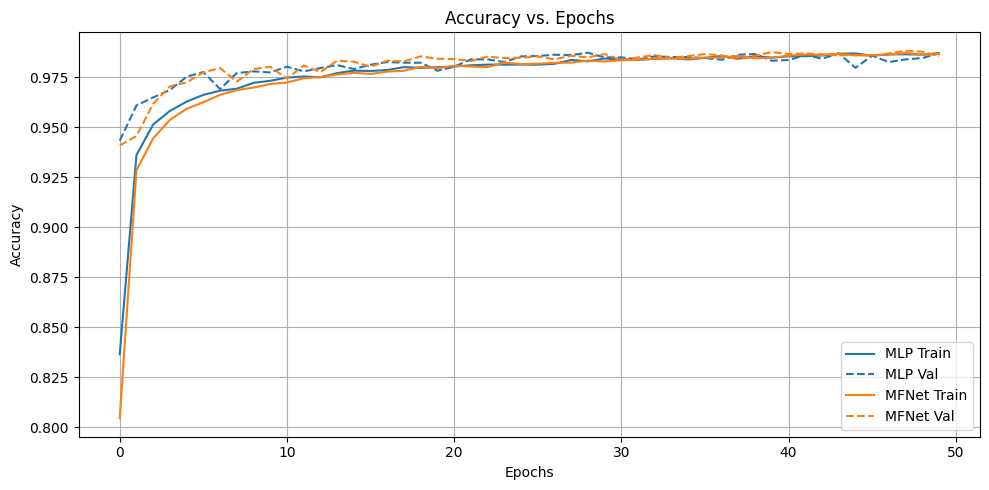

In [ ]:
#@title Plot accuracy

plt.figure(figsize=(10, 5))
plt.subplot(1, 1, 1)
for model_name, history in dataset_histories.items():
    # Plot training accuracy with solid line
    p = plt.plot(history['train_acc'], label=f'{model_name} Train', linestyle='-')
    color = p[0].get_color()
    # Plot validation accuracy with dashed line and same color
    plt.plot(history['val_acc'], label=f'{model_name} Val', linestyle='--', color=color)

plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#@title Plot average peak memory consumption

plt.figure(figsize=(8, 6))

model_names_list = []
avg_mem_allocated = []

for model_name, history in dataset_histories.items():
    if 'mem_allocated' in history:
        model_names_list.append(model_name)
        avg_mem_allocated.append(np.mean(history['mem_allocated']))

# Create a bar chart
plt.bar(model_names_list, avg_mem_allocated, color=['skyblue', 'lightcoral', 'lightgreen'])

plt.title('Average Peak GPU Memory Allocated Across Epochs')
plt.xlabel('Model')
plt.ylabel('Average Peak Memory (GB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#@title Checking Gradient Flow

def check_gradient_flow(model_name, model, x_dummy, y_dummy):
    print(f"\n--- Checking {model_name} ---")

    # 3. Forward pass
    acts, scores = model.forward_all(x_dummy)

    # 4. Compute loss ONLY on the LAST layer's score
    # If layers are decoupled (Forward-only), this loss should NOT affect the first layer's weights.
    loss_last = F.cross_entropy(scores[-1], y_dummy)

    # 5. Backpropagate
    model.zero_grad()
    loss_last.backward()

    # 6. Check gradients on the FIRST layer's weights
    # Identify the first layer based on model type
    if isinstance(model, MFNet):
        first_layer = model.blocks[0].fc
    elif isinstance(model, CNN_MFNet):
        first_layer = model.blocks[0].feature_extractor[0]
    elif isinstance(model, ResNet_MFNet):
        first_layer = model.conv1 # Stem
    else:
        print("Unknown model type")
        return

    first_layer_grads = first_layer.weight.grad

    if first_layer_grads is not None and first_layer_grads.abs().sum() > 0:
        print(f"Result: Gradients DO flow to the first layer.")
        print("Conclusion: Still coupled (Deep Supervision).")
    else:
        print(f"Result: No gradients found on the first layer.")
        print("Conclusion: DECOUPLED. True Layer-wise learning.")

# 1. MFNet Verification
# Create a small dummy MFNet
in_dim_mlp = 3 * 32 * 32 # Approx size
mf_net = MFNet(in_dim_mlp, 10, [100, 100]).to(DEVICE)
x_mlp = torch.randn(2, in_dim_mlp).to(DEVICE)
y_dummy = torch.randint(0, 10, (2,)).to(DEVICE)
check_gradient_flow("MFNet", mf_net, x_mlp, y_dummy)

# 2. CNN_MFNet Verification
# Create a small dummy CNN_MFNet
cnn_mf = CNN_MFNet(3, 10, [{'out_channels': 16}, {'out_channels': 32}], 32).to(DEVICE)
x_cnn = torch.randn(2, 3, 32, 32).to(DEVICE)
check_gradient_flow("CNN_MFNet", cnn_mf, x_cnn, y_dummy)

# 3. ResNet_MFNet Verification
res_mf = ResNet_MFNet(ncls=10, layers=[2, 2, 2, 2]).to(DEVICE)
x_res = torch.randn(2, 3, 256, 256).to(DEVICE)
check_gradient_flow("ResNet_MFNet", res_mf, x_res, y_dummy)

# 4. Check if Validation Set exists
print("\n--- Dataset Verification ---")
print(f"Validation Set Exists: {'dl_val' in locals() and dl_val is not None}")
if 'dl_test' in locals() and dl_test is not None:
    print("Stored 'accuracy' scores correspond to the: TEST set (dl_test)")

In [13]:
import time
import numpy as np

def train_mono_forward_model_time(model, dl_train, dl_val, max_time=60, lr=3e-4, prefix="[MF Time]"):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_acc': [], 'val_acc': [], 'time': []}

    start_time = time.time()
    ep = 0

    while True:
        ep += 1
        model.train()
        tot, corr = 0, 0

        for batch in dl_train:
            # Check if we exceeded time during the epoch
            if time.time() - start_time >= max_time:
                break

            if isinstance(batch, dict):
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else:
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)

            g = model.train_step(x, y, opt)

            with torch.no_grad():
                pred = g.argmax(dim=1)
                corr += (pred==y).sum().item()
                tot += x.size(0)

        current_time = time.time() - start_time
        tr_acc = corr / tot if tot > 0 else 0.0

        # Validation phase
        model.eval()
        val_acc = test_model(model, dl_val)

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['time'].append(current_time)

        print(f'{prefix} epoch {ep:02d} | time: {current_time:.1f}s | train_acc={tr_acc:.3f} | val_acc={val_acc:.3f}')

        if current_time >= max_time:
            print(f'{prefix} Time limit reached!')
            break

    return model, history


def train_backprop_model_time(model, dl_train, dl_val, max_time=60, lr=3e-4, prefix="[BP Time]"):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_acc': [], 'val_acc': [], 'time': []}

    start_time = time.time()
    ep = 0

    while True:
        ep += 1
        model.train()
        train_corr = 0
        train_tot = 0

        for batch in dl_train:
            if time.time() - start_time >= max_time:
                break

            if isinstance(batch, dict):
                x, y = batch['image'].to(DEVICE), batch['label'].to(DEVICE)
            else:
                x, y = batch[0].to(DEVICE), batch[1].to(DEVICE)

            logits = model(x)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad()
            loss.backward()
            opt.step()

            pred = logits.argmax(dim=1)
            train_corr += (pred==y).sum().item()
            train_tot += x.size(0)

        current_time = time.time() - start_time
        train_acc = train_corr / train_tot if train_tot > 0 else 0.0
        val_acc = test_model(model, dl_val)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['time'].append(current_time)

        print(f'{prefix} epoch {ep:02d} | time: {current_time:.1f}s | train_acc={train_acc:.3f} | val_acc={val_acc:.3f}')

        if current_time >= max_time:
            print(f'{prefix} Time limit reached!')
            break

    return model, history

In [ ]:
def train_kfold_time_based(model_class, dataset_name, k_folds=5, batch_size=256, max_time=60, lr=3e-4, prefix="[K-Fold Time]", model_args={}):
    print(f"\n====== Time-Based K-Fold ({k_folds} folds, {max_time}s per fold) on {dataset_name} ======")

    info = dataset_info.get(dataset_name)
    DatasetClass = info['class']
    mean, std = info['mean_std']
    is_rgb = info['is_rgb']
    IN_CH = info['in_channels']

    # Transforms
    tv_transforms_list = [T.ToTensor()]
    if not is_rgb and IN_CH == 3:
        tv_transforms_list.append(T.Grayscale(num_output_channels=3))
    tv_transforms_list.append(T.Normalize(mean, std))
    tv_transform = T.Compose(tv_transforms_list)

    tg_transform = ImageTransform(T.Compose([
        lambda x: x.float() / 255.0,
        T.Normalize(mean, std)
    ]))

    if dataset_name == 'UCMerced':
        full_dataset = DatasetClass(root='./data', split='train', download=True, checksum=True, transforms=tg_transform)
    else:
        full_dataset = DatasetClass(root='./data', train=True, download=True, transform=tv_transform)

    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = {}
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
        print(f'\nFOLD {fold}')
        print('--------------------------------')
        train_subsampler = SubsetRandomSampler(train_ids)
        val_subsampler = SubsetRandomSampler(val_ids)

        trainloader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_subsampler, num_workers=2)
        valloader = DataLoader(full_dataset, batch_size=batch_size, sampler=val_subsampler, num_workers=2)

        model = model_class(**model_args)

        if 'MF' in prefix:
             model, hist = train_mono_forward_model_time(model, trainloader, valloader, max_time=max_time, lr=lr, prefix=f'{prefix} Fold {fold}')
        else:
             model, hist = train_backprop_model_time(model, trainloader, valloader, max_time=max_time, lr=lr, prefix=f'{prefix} Fold {fold}')

        fold_acc = hist['val_acc'][-1]
        fold_accuracies.append(fold_acc)
        results[fold] = fold_acc
        print(f'Fold {fold} Accuracy: {fold_acc:.4f}')

        del model
        gc.collect()
        torch.cuda.empty_cache()

    avg_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f'\nAverage Accuracy over {k_folds} folds ({max_time}s each): {avg_acc:.4f} ± {std_acc:.4f}')
    return results

# --- Execution Example ---
max_time_per_fold = 60 * 5 # seconds
all_time_kfold_results = {}

for dataset_name in dataset_names:
    mlp_layers, conv_filters, cnn_mlp_hidden_dims, cnn_mf_layers_config, resnet_num_classes = get_model_configs(dataset_name)
    info = dataset_info.get(dataset_name)
    IN_CH, NCLS, IMG = info['in_channels'], info['n_classes'], info['img_size']

    for model_name in model_names:
        print(f"\n>>> Running Time-Based K-Fold for Model: {model_name}")
        model_args = {'img_channels': IN_CH}
        if 'MF' in model_name:
            model_class = ResNet_MFNet
            model_args['ncls'] = resnet_num_classes
            model_args['layers'] = [2, 2, 2, 2]
            prefix = "[ResNet_MF]"
            lr = lr_mf
        else:
            model_class = ResNet18
            model_args['num_classes'] = resnet_num_classes
            prefix = "[ResNet18]"
            lr = lr_bp

        res = train_kfold_time_based(
            model_class=model_class,
            dataset_name=dataset_name,
            k_folds=k_folds,
            batch_size=batch_size,
            max_time=max_time_per_fold,
            lr=lr,
            prefix=prefix,
            model_args=model_args
        )
        all_time_kfold_results[f"{dataset_name}_{model_name}"] = res



>>> Running Time-Based K-Fold for Model: CNN_BP

====== Time-Based K-Fold (3 folds, 300s per fold) on CIFAR10 ======


100%|██████████| 170M/170M [00:57<00:00, 2.98MB/s]



FOLD 0
--------------------------------
[ResNet18] Fold 0 epoch 01 | time: 14.8s | train_acc=0.463 | val_acc=0.512
[ResNet18] Fold 0 epoch 02 | time: 32.3s | train_acc=0.614 | val_acc=0.613
[ResNet18] Fold 0 epoch 03 | time: 51.0s | train_acc=0.689 | val_acc=0.645
[ResNet18] Fold 0 epoch 04 | time: 69.4s | train_acc=0.737 | val_acc=0.666
[ResNet18] Fold 0 epoch 05 | time: 89.1s | train_acc=0.784 | val_acc=0.680
[ResNet18] Fold 0 epoch 06 | time: 108.5s | train_acc=0.823 | val_acc=0.684
[ResNet18] Fold 0 epoch 07 | time: 129.4s | train_acc=0.857 | val_acc=0.672
[ResNet18] Fold 0 epoch 08 | time: 149.3s | train_acc=0.885 | val_acc=0.703
[ResNet18] Fold 0 epoch 09 | time: 168.6s | train_acc=0.908 | val_acc=0.680
[ResNet18] Fold 0 epoch 10 | time: 188.3s | train_acc=0.927 | val_acc=0.703
[ResNet18] Fold 0 epoch 11 | time: 208.0s | train_acc=0.942 | val_acc=0.707
[ResNet18] Fold 0 epoch 12 | time: 228.7s | train_acc=0.952 | val_acc=0.695
[ResNet18] Fold 0 epoch 13 | time: 248.6s | train_ac

KeyboardInterrupt: 

In [ ]:
#@title Verification of model architectures

print("=== Verifying Model Architectures ===")

# 1. Verify MLP (CIFAR10 Config: 3x2000 hidden layers)
print("\n--- MLP (CIFAR10 Config) ---")
try:
    mlp_cifar = MLP(in_dim=3072, ncls=10, hidden=[2000, 2000, 2000])
    print(mlp_cifar)
except Exception as e:
    print(f"Error instantiating MLP: {e}")

# 2. Verify CNN_BP (Standard Config: [64, 128, 256, 512])
print("\n--- CNN_BP ---")
try:
    # Assuming input size 32x32 for CIFAR10
    cnn_bp_ver = CNN_BP(in_channels=3, img_size=32, ncls=10, conv_filters=[64, 128, 256, 512], mlp_hidden_dims=[])
    print(cnn_bp_ver)

    # Check the final linear layer input size calculation
    # 32 -> 16 -> 8 -> 4 -> 2. Spatial 2x2. Channels 512. Flattened: 512*2*2 = 2048.
    print(f"CNN_BP Final Linear Layer Input Features: {cnn_bp_ver.output_layer.in_features}")
    if cnn_bp_ver.output_layer.in_features == 512 * 2 * 2:
        print("Verification: Final feature map size matches expectation (512 * 2 * 2).")
    else:
        print(f"Verification WARNING: Final feature map size {cnn_bp_ver.output_layer.in_features} != 2048")
except Exception as e:
    print(f"Error instantiating CNN_BP: {e}")

# 3. Verify CNN_MFNet (Standard Config)
print("\n--- CNN_MFNet ---")
try:
    cnn_mf_config = [
        {'out_channels': 64},
        {'out_channels': 128},
        {'out_channels': 256},
        {'out_channels': 512}
    ]
    cnn_mf_ver = CNN_MFNet(in_channels=3, ncls=10, layers_config=cnn_mf_config, img_size=32)
    print(cnn_mf_ver)
except Exception as e:
    print(f"Error instantiating CNN_MFNet: {e}")

# 4. Verify ResNet_MFNet
print("\n--- ResNet_MFNet ---")
try:
    resnet_mf_ver = ResNet_MFNet(ncls=10, layers=[2, 2, 2, 2], img_channels=3)
    print(resnet_mf_ver)
except Exception as e:
    print(f"Error instantiating ResNet_MFNet: {e}")

In [24]:
def train_kfold_time_based_with_history(model_class, dataset_name, k_folds=5, batch_size=256, max_time=60, lr=3e-4, prefix="[K-Fold Time]", model_args={}):
    print(f"\n====== Time-Based K-Fold ({k_folds} folds, {max_time}s per fold) on {dataset_name} ======")

    info = dataset_info.get(dataset_name)
    DatasetClass = info['class']
    mean, std = info['mean_std']
    is_rgb = info['is_rgb']
    IN_CH = info['in_channels']

    # Transforms
    tv_transforms_list = [T.ToTensor()]
    if not is_rgb and IN_CH == 3:
        tv_transforms_list.append(T.Grayscale(num_output_channels=3))
    tv_transforms_list.append(T.Normalize(mean, std))
    tv_transform = T.Compose(tv_transforms_list)

    tg_transform = ImageTransform(T.Compose([
        lambda x: x.float() / 255.0,
        T.Normalize(mean, std)
    ]))

    if dataset_name == 'UCMerced':
        full_dataset = DatasetClass(root='./data', split='train', download=True, checksum=True, transforms=tg_transform)
    else:
        full_dataset = DatasetClass(root='./data', train=True, download=True, transform=tv_transform)

    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = {}
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
        print(f'\nFOLD {fold}')
        print('--------------------------------')
        train_subsampler = SubsetRandomSampler(train_ids)
        val_subsampler = SubsetRandomSampler(val_ids)

        trainloader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_subsampler, num_workers=2)
        valloader = DataLoader(full_dataset, batch_size=batch_size, sampler=val_subsampler, num_workers=2)

        model = model_class(**model_args)

        if 'MF' in prefix:
             model, hist = train_mono_forward_model_time(model, trainloader, valloader, max_time=max_time, lr=lr, prefix=f'{prefix} Fold {fold}')
        else:
             model, hist = train_backprop_model_time(model, trainloader, valloader, max_time=max_time, lr=lr, prefix=f'{prefix} Fold {fold}')

        fold_acc = hist['val_acc'][-1]
        fold_accuracies.append(fold_acc)

        # SAVE HISTORY FOR PLOTTING
        results[fold] = {'accuracy': fold_acc, 'history': hist}

        print(f'Fold {fold} Accuracy: {fold_acc:.4f}')

        del model
        gc.collect()
        torch.cuda.empty_cache()

    avg_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f'\nAverage Accuracy over {k_folds} folds ({max_time}s each): {avg_acc:.4f} \u00b1 {std_acc:.4f}')
    return results

# --- Execution Example ---
max_time_per_fold = int(60 * 5) # seconds
all_time_kfold_results = {}

for dataset_name in dataset_names:
    mlp_layers, conv_filters, cnn_mlp_hidden_dims, cnn_mf_layers_config, resnet_num_classes = get_model_configs(dataset_name)
    info = dataset_info.get(dataset_name)
    IN_CH, NCLS, IMG = info['in_channels'], info['n_classes'], info['img_size']
    in_dim = IN_CH * IMG * IMG

    for model_name in model_names:
        print(f"\n>>> Running Time-Based K-Fold for Model: {model_name}")

        model_class = None
        model_args = {}
        prefix = ""
        current_lr = lr_bp

        if model_name == 'MLP':
            model_class = MLP
            model_args = {'in_dim': in_dim, 'ncls': NCLS, 'hidden': mlp_layers}
            prefix = "[MLP]"
            current_lr = lr_bp
        elif model_name == 'CNN_BP':
            model_class = CNN_BP
            model_args = {
                'in_channels': IN_CH, 'img_size': IMG, 'ncls': NCLS,
                'conv_filters': conv_filters, 'mlp_hidden_dims': cnn_mlp_hidden_dims
            }
            prefix = "[CNN_BP]"
            current_lr = lr_bp
        elif model_name == 'MFNet':
            model_class = MFNet
            model_args = {'in_dim': in_dim, 'ncls': NCLS, 'layers': mlp_layers}
            prefix = "[MFNet]"
            current_lr = lr_mf
        elif model_name == 'CNN_MF':
            model_class = CNN_MFNet
            model_args = {
                'in_channels': IN_CH, 'ncls': NCLS,
                'layers_config': cnn_mf_layers_config, 'img_size': IMG
            }
            prefix = "[CNN_MF]"
            current_lr = lr_mf
        elif model_name == 'ResNet18':
            model_class = ResNet18
            model_args = {'num_classes': resnet_num_classes, 'img_channels': IN_CH}
            prefix = "[ResNet18]"
            current_lr = lr_bp
        elif model_name == 'ResNet_MF':
            model_class = ResNet_MFNet
            model_args = {'ncls': resnet_num_classes, 'layers': [2, 2, 2, 2], 'img_channels': IN_CH}
            prefix = "[ResNet_MF]"
            current_lr = lr_mf
        elif model_name == 'Plain18_MFNet':
            model_class = Plain18_MFNet
            model_args = {'ncls': resnet_num_classes, 'layers': [2, 2, 2, 2], 'img_channels': IN_CH}
            prefix = "[Plain18_MFNet]"
            current_lr = lr_mf
        elif model_name == 'Plain18_BP':
            model_class = Plain18_BP
            model_args = {'num_classes': resnet_num_classes, 'img_channels': IN_CH}
            prefix = "[Plain18_BP]"
            current_lr = lr_bp
        else:
            print(f"Warning: Unknown model {model_name}, skipping.")
            continue

        res = train_kfold_time_based_with_history(
            model_class=model_class,
            dataset_name=dataset_name,
            k_folds=k_folds,
            batch_size=batch_size,
            max_time=max_time_per_fold,
            lr=current_lr,
            prefix=prefix,
            model_args=model_args
        )
        all_time_kfold_results[f"{dataset_name}_{model_name}"] = res


>>> Running Time-Based K-Fold for Model: Plain18_MFNet

====== Time-Based K-Fold (3 folds, 300s per fold) on UCMerced ======

FOLD 0
--------------------------------
[Plain18_MFNet] Fold 0 epoch 01 | time: 0.7s | train_acc=0.092 | val_acc=0.045
[Plain18_MFNet] Fold 0 epoch 02 | time: 1.9s | train_acc=0.133 | val_acc=0.064
[Plain18_MFNet] Fold 0 epoch 03 | time: 3.0s | train_acc=0.186 | val_acc=0.052
[Plain18_MFNet] Fold 0 epoch 04 | time: 4.2s | train_acc=0.265 | val_acc=0.048
[Plain18_MFNet] Fold 0 epoch 05 | time: 5.3s | train_acc=0.273 | val_acc=0.048
[Plain18_MFNet] Fold 0 epoch 06 | time: 6.4s | train_acc=0.306 | val_acc=0.043
[Plain18_MFNet] Fold 0 epoch 07 | time: 7.6s | train_acc=0.321 | val_acc=0.036
[Plain18_MFNet] Fold 0 epoch 08 | time: 8.7s | train_acc=0.364 | val_acc=0.040
[Plain18_MFNet] Fold 0 epoch 09 | time: 9.9s | train_acc=0.377 | val_acc=0.064
[Plain18_MFNet] Fold 0 epoch 10 | time: 11.0s | train_acc=0.390 | val_acc=0.052
[Plain18_MFNet] Fold 0 epoch 11 | time: 12

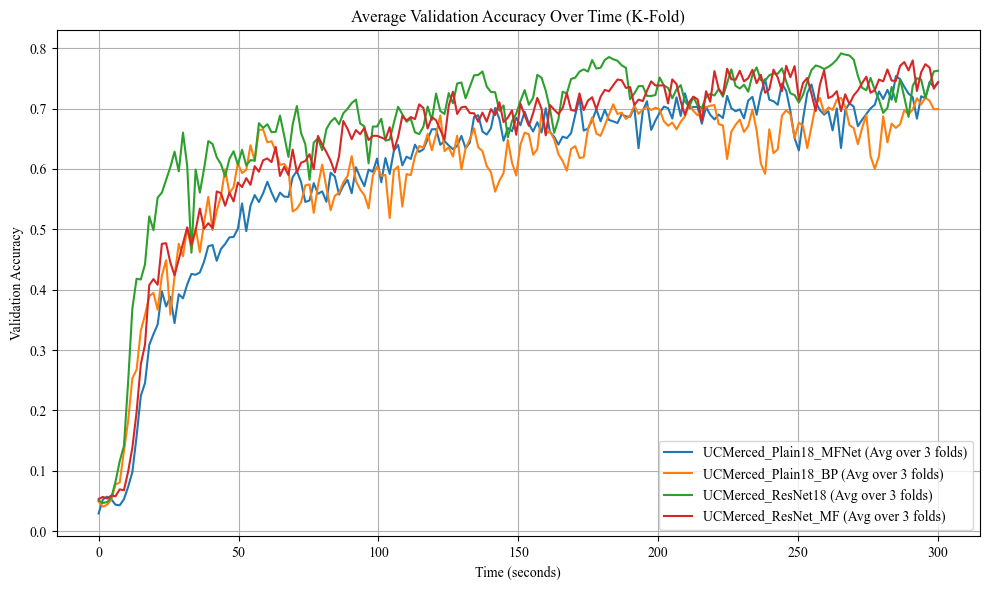

In [25]:
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np

# Install and register Times New Roman using the system package
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
if not os.path.exists(font_path):
    print("Installing official Times New Roman font via apt-get...")
    os.system('echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections')
    os.system('apt-get install -qq -y ttf-mscorefonts-installer')

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
else:
    print("Failed to find the font. Falling back to default serif.")
    plt.rcParams["font.family"] = "serif"

def plot_kfold_time_history(all_time_results, max_time):
    plt.figure(figsize=(10, 6))

    # Create a common time grid to average across different folds
    common_time = np.linspace(0, max_time, 200)

    for model_key, folds_data in all_time_results.items():
        interpolated_accs = []

        for fold, data in folds_data.items():
            if isinstance(data, dict) and 'history' in data:
                times = data['history']['time']
                accs = data['history']['val_acc']

                # Ensure time is monotonically increasing
                times, indices = np.unique(times, return_index=True)
                accs = np.array(accs)[indices]

                if len(times) > 1:
                    # Interpolate to the common grid
                    f_interp = interp1d(times, accs, kind='linear', bounds_error=False, fill_value=(accs[0], accs[-1]))
                    interpolated_accs.append(f_interp(common_time))

        if interpolated_accs:
            avg_acc = np.mean(interpolated_accs, axis=0)
            plt.plot(common_time, avg_acc, label=f'{model_key} (Avg over {len(interpolated_accs)} folds)')

    plt.title('Average Validation Accuracy Over Time (K-Fold)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Note: Ensure all_time_kfold_results and max_time_per_fold are defined in your kernel before running
if 'all_time_kfold_results' in locals() and 'max_time_per_fold' in locals():
    plot_kfold_time_history(all_time_kfold_results, max_time_per_fold)
else:
    print("Variable 'all_time_kfold_results' or 'max_time_per_fold' not found. Please run the training cells first.")